In [1]:
file_path = r'D:\code\log1.txt'

In [2]:
import numpy as np

In [2]:
lines=None
with open(file_path, 'r', encoding='utf-8') as file:
    lines = file.readlines()
print(lines[0])



90266,168.00,957.92,16.86,1.26,17.31,1.31,16.65,1.23,16.48,1.18,16.48,1.11,16.59,1.14,16.78,1.14,17.15,1.12,16.66,1.29,17.44,1.21,16.93,1.12,16.74,1.24,16.29,1.16,16.99,1.22,16.24,1.19,16.37,1.12,17.39,1.15,16.28,1.12,17.78,1.18,16.53,1.22,17.92,1.23,14.59,1.25,17.52,1.15,16.75,1.22,16.61,1.19,18.67,1.21,14.63,1.28,16.53,1.25,17.83,1.22,17.48,1.18,15.91,1.25,16.28,1.25,17.52,1.21,15.20,1.20,17.98,1.27,14.47,1.25,16.96,1.18,17.48,1.22,17.07,1.21,14.98,1.23,16.53,1.22,16.49,1.24,16.69,1.09,16.67,1.19,16.95,1.24,16.42,1.13,16.77,1.18,16.66,1.14,16.52,1.11,18.01,1.19,17.13,1.18,15.74,1.19,17.43,1.21,17.59,1.13,16.43,1.08,17.04,1.24,16.17,1.19,17.20,1.23,15.50,1.22,16.71,1.22



In [55]:
time = range(20)  # x 轴为时间（单位：秒）
zhenlv1 = [60 + (i % 10) for i in time]  # 示例帧率数据
print(zhenlv1)

[60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69]


In [3]:
a = []

for item in lines :
    str1 = item.replace('\n','').split(',')
    str1 = [elem for elem in str1 if elem != '']  # 
    a.append([float(item) for item in str1])


In [4]:
id_ = []
id_len = []
for item in a :
    id_.append( int(item[0]))  #首帧编号
    num = len(item)- 3

    if(num % 2) :num = num /2 + 1 
    else : num = num / 2

    id_len.append( int(num) )

In [5]:
normal = 0
loss = 0
loss_add = 0
sum_zhen = 0 
loss_id = []
for i in range(len(id_)-1):
    if id_[i] + id_len[i] == id_[i+1]:
        normal += 1 
    else : 
        loss += 1
        loss_id.append(id_len[i])
        loss_add += id_[i+1] - (id_[i] + id_len[i])

In [53]:
for i in range(1,len(id_)-1):
    sum_zhen += id_len[i]

In [54]:
print(len(id_)-1)
print(normal)
print(loss)
print(loss_add,sum_zhen)

550
218
332
1354 101836


In [11]:
zhenlv = []
for item in a :
    for i in range(3,len(item),2):
        zhenlv.append(  float(1000) / item[i])

In [30]:
zhenlv = []
for item in a :
    num = float(0);
    j = float(0);
    for i in range(3,len(item),2):
        if(item[i]< 8.3368071):
            num += 119.95
        else:
            num += float(1000) / item[i]
        j += 1

    zhenlv.append(float(num/j))

In [31]:
for i in zhenlv :
    if i > 119.95 :
        print(1)

In [16]:
len(zhenlv)

551

In [10]:
zhenlv = []
for item in a :
    for i in range(len(item)):
        if(item[i] <= 35 and item[i] >= 8.30) :
            zhenlv.append(  float(1000) / item[i])


In [8]:
with open('./zhenlv.performance', 'w') as f:
    for i in zhenlv:
        f.write(str(i)+'\n')  # 写入字符串到文件

In [34]:
import numpy as np

In [39]:
filtered_data = [num for num in zhenlv if num > 65]
fps_array = np.array(filtered_data)
sorted_fps = np.sort(fps_array)

# 计算百分之 1 和百分之 5 的索引
index_1_low = int(len(sorted_fps) * 0.01)
index_5_low = int(len(sorted_fps) * 0.05)

# 获取对应的值
percentile_1_low = sorted_fps[index_1_low]
percentile_5_low = sorted_fps[index_5_low]

low_frame_count = sum(1 for fps in filtered_data if fps < 117)

stutter_rate = (low_frame_count / len(filtered_data)) * 100 

print(f"百分之 1 低帧: {percentile_1_low}")
print(f"百分之 5 低帧: {percentile_5_low}")
print(f"平均帧: {sum(filtered_data)/len(filtered_data)}")
print(f"轻微卡顿率: {stutter_rate:.2f}%")

百分之 1 低帧: 113.78680398787301
百分之 5 低帧: 116.89796471564759
平均帧: 118.67291508998885
轻微卡顿率: 5.95%


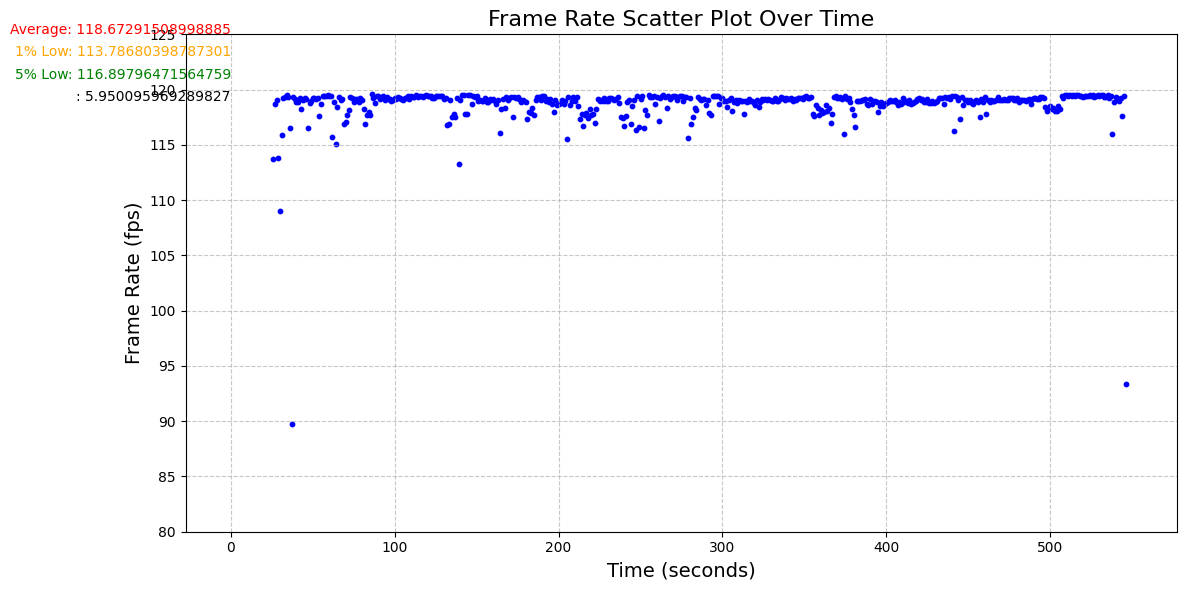

In [51]:
import matplotlib.pyplot as plt


# 示例数据
total_time = 551  # 总时间（秒）
time = range(total_time)  # x 轴为时间（单位：秒）

# 创建散点图
plt.figure(figsize=(12, 6))
plt.scatter(time, zhenlv, color='blue', s=10)  # s 为点的大小

# 设置标题和标签
plt.title('Frame Rate Scatter Plot Over Time', fontsize=16)
plt.xlabel('Time (seconds)', fontsize=14)
plt.ylabel('Frame Rate (fps)', fontsize=14)

# 设置 y 轴范围
plt.ylim(80, 125)

plt.text(0,125, f'Average: {sum(filtered_data)/len(filtered_data)}', fontsize=10, color='red', ha='right')
plt.text(0, 123, f'1% Low: {percentile_1_low}', fontsize=10, color='orange', ha='right')
plt.text(0, 121, f'5% Low: {percentile_5_low}', fontsize=10, color='green', ha='right')
plt.text(0, 119, f': {stutter_rate}', fontsize=10, color='black', ha='right')

# 添加网格线
plt.grid(True, linestyle='--', alpha=0.7)

# 显示图形
plt.tight_layout()  # 自适应布局
plt.show()


In [15]:
import subprocess
import signal
import os
import json
import sys
#sudo ios tunnel start && ios tunnel start --userspace
#curl http://127.0.0.1:60105/tunnels
program = r'C:\Users\Administrator\AppData\Roaming\npm\bin\ios.exe'  # 替换为你想要启动的程序
program = r'curl'  # 替换为你想要启动的程序
args = ['tunnel', 'start', '--userspace']  # 替换为实际的参数列表
args = ['http://127.0.0.1:60105/tunnels']  # 替换为实际的参数列表
# 启动程序
process = subprocess.Popen([program] + args, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)

# 等待程序结束
stdout, stderr = process.communicate()
try:
    data = json.loads(stdout.replace('[','').replace(']',''))
    print("转换后的字典：", data)
except json.JSONDecodeError as e:
    print("解析错误：", e)
print(type(data['userspaceTunPort']))
# 打印程序的输出
#print(type(stdout))
#print('stdout:', stdout)

'''
# 发送终止信号
try:
    # Unix-like系统
    os.kill(process.pid, signal.SIGTERM)
except AttributeError:
    # Windows系统
    process.send_signal(signal.CTRL_C_EVENT)
'''

转换后的字典： {'address': 'fd5b:78bc:1916::1', 'rsdPort': 58299, 'udid': '00008027-000A61C81107002E', 'userspaceTun': True, 'userspaceTunPort': 60106}
<class 'int'>


'\n# 发送终止信号\ntry:\n    # Unix-like系统\n    os.kill(process.pid, signal.SIGTERM)\nexcept AttributeError:\n    # Windows系统\n    process.send_signal(signal.CTRL_C_EVENT)\n'